In [2]:
pip install pandas scipy matplotlib seaborn statsmodels jupyter


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

# IMPORTING DATASET

In [4]:
df = pd.read_csv("F:\Portfolio Projects\marketing_AB.csv\marketing_AB.csv")
print(df.shape)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\hinaj\AppData\Local\Temp\ipykernel_23808\1095992812.py:1: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("F:\Portfolio Projects\marketing_AB.csv\marketing_AB.csv")


(588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


Checking Data Quality

In [6]:
print("MISSING VALUES")
print(df.isnull().sum())

# No missing values found

MISSING VALUES
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64


In [7]:
print("DUPLICATE ROWS")
print(f"Number of duplicates: {df.duplicated().sum()}")

# No duplicate values 

DUPLICATE ROWS
Number of duplicates: 0


In [8]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [9]:
print("UNIQUE VALUES IN KEY COLUMNS")
print(f"Test groups: {df['test group'].unique()}")
print(f"Converted values: {df['converted'].unique()}")

# No discrepancy found

UNIQUE VALUES IN KEY COLUMNS
Test groups: ['ad' 'psa']
Converted values: [False  True]


Checking Group-wise Distribution 

In [10]:
print("GROUP DISTRIBUTION")
group_counts = df.groupby('test group')['user id'].nunique()
print(group_counts)

print("\nPERCENTAGE SPLIT")
total_users = group_counts.sum()
for group, count in group_counts.items():
    print(f"{group}: {count:,} users ({count/total_users*100:.1f}%)")

print(f"\nTotal unique users: {total_users:,}")

GROUP DISTRIBUTION
test group
ad     564577
psa     23524
Name: user id, dtype: int64

PERCENTAGE SPLIT
ad: 564,577 users (96.0%)
psa: 23,524 users (4.0%)

Total unique users: 588,101


In [11]:
# Calculate conversion rate for each group

conversion_rates = df.groupby('test group')['converted'].agg(['sum', 'count', 'mean'])
conversion_rates.columns = ['Conversions', 'Total Users', 'Conversion Rate']
conversion_rates['Conversion Rate %'] = (conversion_rates['Conversion Rate'] * 100).round(2)

print("CONVERSION RATE BY GROUP")
print(conversion_rates)

CONVERSION RATE BY GROUP
            Conversions  Total Users  Conversion Rate  Conversion Rate %
test group                                                              
ad                14423       564577         0.025547               2.55
psa                 420        23524         0.017854               1.79


Hypothesis Testing

In [12]:
from scipy import stats
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Extract values for each group
ad_users = conversion_rates.loc['ad', 'Total Users']
ad_conversions = conversion_rates.loc['ad', 'Conversions']

psa_users = conversion_rates.loc['psa', 'Total Users']
psa_conversions = conversion_rates.loc['psa', 'Conversions']

# Conversion rates
ad_rate = ad_conversions / ad_users
psa_rate = psa_conversions / psa_users

# Run two-proportion z-test
count = np.array([ad_conversions, psa_conversions])
nobs = np.array([ad_users, psa_users])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(" HYPOTHESIS TEST RESULTS ")
print(f"Ad Conversion Rate:  {ad_rate:.4f} ({ad_rate*100:.2f}%)")
print(f"PSA Conversion Rate: {psa_rate:.4f} ({psa_rate*100:.2f}%)")
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"\nSignificance level: 0.05")

if p_value < 0.05:
    print("Result: REJECT the null hypothesis")
    print("The ads perform significantly better than the PSA ✓")
else:
    print("Result: FAIL TO REJECT the null hypothesis")
    print("No significant difference found between ads and PSA")

 HYPOTHESIS TEST RESULTS 
Ad Conversion Rate:  0.0255 (2.55%)
PSA Conversion Rate: 0.0179 (1.79%)

Z-statistic: 7.3701
P-value: 0.000000

Significance level: 0.05
Result: REJECT the null hypothesis
The ads perform significantly better than the PSA ✓


Important Findings 

In [13]:
print(" BUSINESS IMPACT ")

# Relative uplift
uplift = (ad_rate - psa_rate) / psa_rate * 100
print(f"Relative uplift from ads: {uplift:.1f}%")

# If PSA group had seen ads instead - how many extra conversions?
extra_conversions = int(psa_users * (ad_rate - psa_rate))
print(f"Extra conversions if PSA group saw ads: {extra_conversions}")

# Overall extra conversions ads drove vs if everyone saw PSA
total_extra = int(ad_users * (ad_rate - psa_rate))
print(f"Extra conversions ads drove vs PSA baseline: {total_extra:,}")

 BUSINESS IMPACT 
Relative uplift from ads: 43.1%
Extra conversions if PSA group saw ads: 180
Extra conversions ads drove vs PSA baseline: 4,342


Exploratory Analysis

 CONVERSION RATE BY DAY 


              Conversions  Total Users  Conversion Rate  Conversion Rate %
most ads day                                                              
Monday               2857        87073         0.032812               3.28
Tuesday              2312        77479         0.029840               2.98
Wednesday            2018        80908         0.024942               2.49
Thursday             1790        82982         0.021571               2.16
Friday               2057        92608         0.022212               2.22
Saturday             1719        81660         0.021051               2.11
Sunday               2090        85391         0.024476               2.45


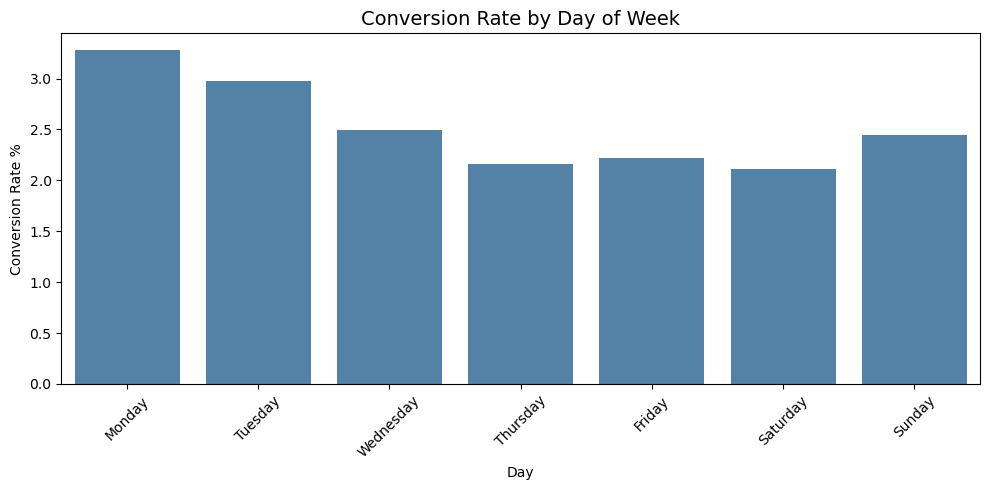


 CONVERSION RATE BY HOUR 
               Conversions  Total Users  Conversion Rate  Conversion Rate %
most ads hour                                                              
0                      102         5536         0.018425               1.84
1                       62         4802         0.012911               1.29
2                       39         5333         0.007313               0.73
3                       28         2679         0.010452               1.05
4                       11          722         0.015235               1.52
5                       16          765         0.020915               2.09
6                       46         2068         0.022244               2.22
7                      116         6405         0.018111               1.81
8                      344        17627         0.019516               1.95
9                      595        31004         0.019191               1.92
10                     838        38939         0.021521     

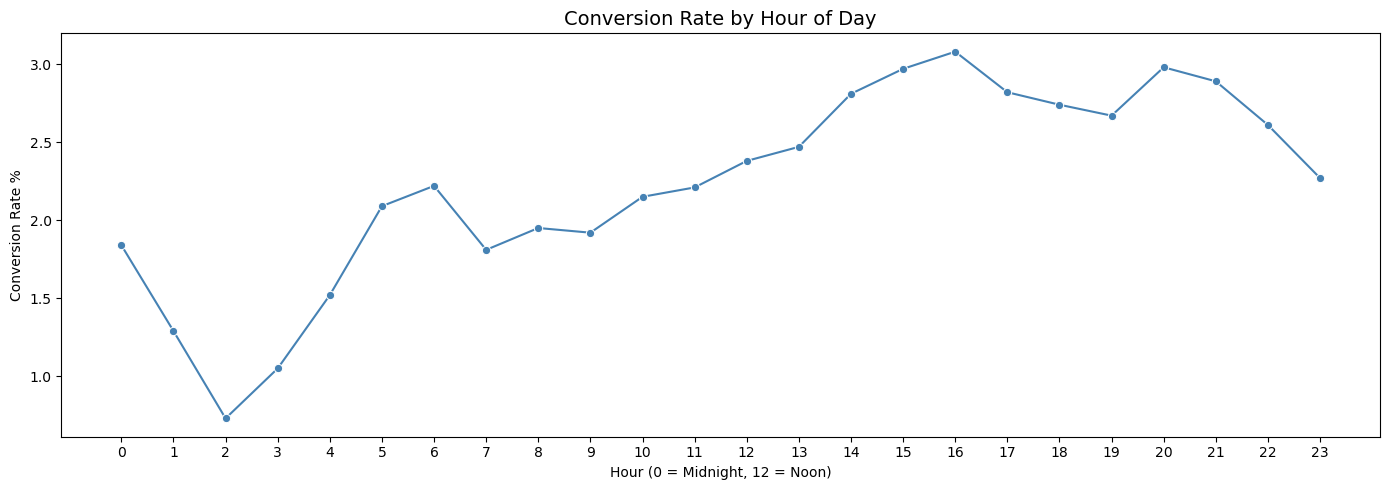

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# PART 1 - Conversion rate by day of week
# ============================================

print(" CONVERSION RATE BY DAY ")
day_analysis = df.groupby('most ads day')['converted'].agg(['sum', 'count', 'mean'])
day_analysis.columns = ['Conversions', 'Total Users', 'Conversion Rate']
day_analysis['Conversion Rate %'] = (day_analysis['Conversion Rate'] * 100).round(2)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_analysis = day_analysis.reindex(day_order)
print(day_analysis)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=day_analysis.index, y=day_analysis['Conversion Rate %'], color='steelblue')
plt.title('Conversion Rate by Day of Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Conversion Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================
# PART 2 - Conversion rate by hour of day
# ============================================

print("\n CONVERSION RATE BY HOUR ")
hour_analysis = df.groupby('most ads hour')['converted'].agg(['sum', 'count', 'mean'])
hour_analysis.columns = ['Conversions', 'Total Users', 'Conversion Rate']
hour_analysis['Conversion Rate %'] = (hour_analysis['Conversion Rate'] * 100).round(2)
print(hour_analysis)

# Plot
plt.figure(figsize=(14, 5))
sns.lineplot(x=hour_analysis.index, y=hour_analysis['Conversion Rate %'], marker='o', color='steelblue')
plt.title('Conversion Rate by Hour of Day', fontsize=14)
plt.xlabel('Hour (0 = Midnight, 12 = Noon)')
plt.ylabel('Conversion Rate %')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

Ad Fatigue Analysis

 AD FATIGUE ANALYSIS 
Total ads distribution (percentiles):
count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
90%          57.000000
95%          88.000000
99%         202.000000
max        2065.000000
Name: total ads, dtype: float64

Conversion Rate by Ad Frequency:
           Conversions  Total Users  Conversion Rate  Conversion Rate %
ad_bucket                                                              
1-5                427       169962         0.002512               0.25
6-10               386        79537         0.004853               0.49
11-20             1036       123334         0.008400               0.84
21-50             3660       125541         0.029154               2.92
51-100            5135        44149         0.116311              11.63
101-200           2892        16360         0.176773              17.68
201-500            788         5128         0

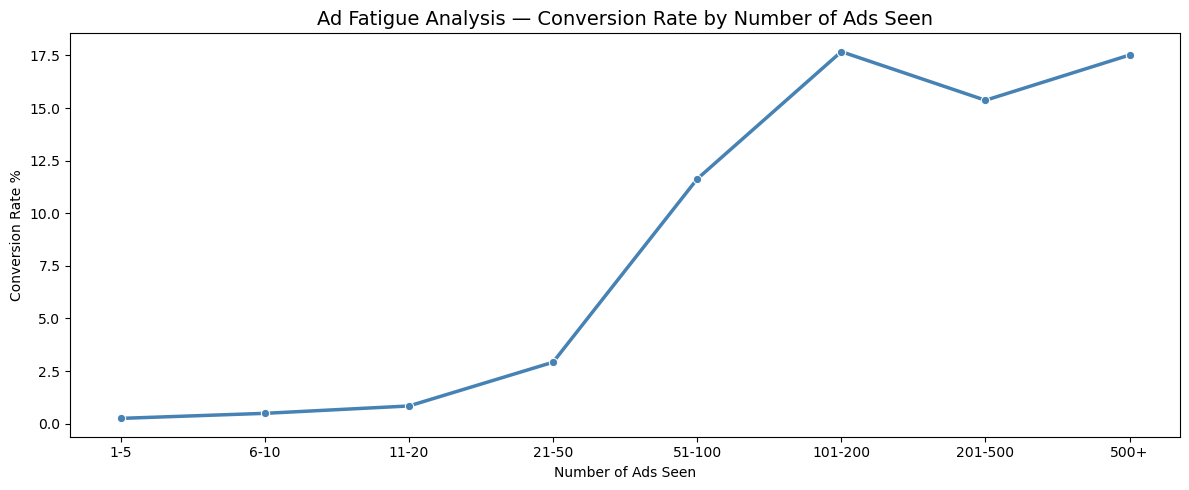

In [15]:
print(" AD FATIGUE ANALYSIS ")

# Look at conversion rate by number of ads seen
# First let's see the distribution of total ads
print("Total ads distribution (percentiles):")
print(df['total ads'].describe(percentiles=[.25, .50, .75, .90, .95, .99]))

# Create ad frequency buckets
df['ad_bucket'] = pd.cut(df['total ads'], 
                          bins=[0, 5, 10, 20, 50, 100, 200, 500, 2000],
                          labels=['1-5', '6-10', '11-20', '21-50', 
                                  '51-100', '101-200', '201-500', '500+'])

# Conversion rate by bucket - only for ad group
ad_group = df[df['test group'] == 'ad']
fatigue_analysis = ad_group.groupby('ad_bucket', observed=True)['converted'].agg(['sum', 'count', 'mean'])
fatigue_analysis.columns = ['Conversions', 'Total Users', 'Conversion Rate']
fatigue_analysis['Conversion Rate %'] = (fatigue_analysis['Conversion Rate'] * 100).round(2)
print("\nConversion Rate by Ad Frequency:")
print(fatigue_analysis)

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(x=fatigue_analysis.index, y=fatigue_analysis['Conversion Rate %'], 
             marker='o', color='steelblue', linewidth=2.5)
plt.title('Ad Fatigue Analysis — Conversion Rate by Number of Ads Seen', fontsize=14)
plt.xlabel('Number of Ads Seen')
plt.ylabel('Conversion Rate %')
plt.tight_layout()
plt.show()